In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
df['job_type_skills'] = df['job_type_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else {})

In [2]:
df_da = df[df["job_title_short"] == "Data Analyst"].copy()
df_da.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
12,Data Analyst,Stagiaire Data Analyst (H/F) - Lyon (69006),"Lyon, France",via Jobijoba,Full-time and Internship,False,France,2023-12-22 13:24:41,False,False,France,NaN,NaN,NaN,Engie,"[sql, php, excel, power bi, sap, jira]","{'analyst_tools': ['excel', 'power bi', 'sap']..."
18,Data Analyst,Data Analyst,"Warsaw, Poland",via Praca Trabajo.org,Full-time,False,Poland,2023-10-16 13:36:54,False,False,Poland,NaN,NaN,NaN,Glovo,"[sql, python, r, redshift, pandas, excel, look...","{'analyst_tools': ['excel', 'looker', 'tableau..."
31,Data Analyst,Stage - Data Analyst F/H,"Paris, France",via LinkedIn,Full-time and Internship,False,France,2023-10-19 13:59:31,False,False,France,NaN,NaN,NaN,GROUPE BON MARCHÉ : Le Bon Marché Rive Gauche ...,[sql],{'programming': ['sql']}
34,Data Analyst,Data Analyst als Marketing Manager Automation ...,"Erlangen, Germany",via Central Illinois Proud Jobs,Full-time,False,Germany,2023-02-23 13:31:28,True,False,Germany,NaN,NaN,NaN,DEFACTO GmbH,[sap],{'analyst_tools': ['sap']}


In [3]:
work_from_home = df_da["job_work_from_home"].value_counts()
work_from_home.head()

job_work_from_home
False    182749
True      13326
Name: count, dtype: int64

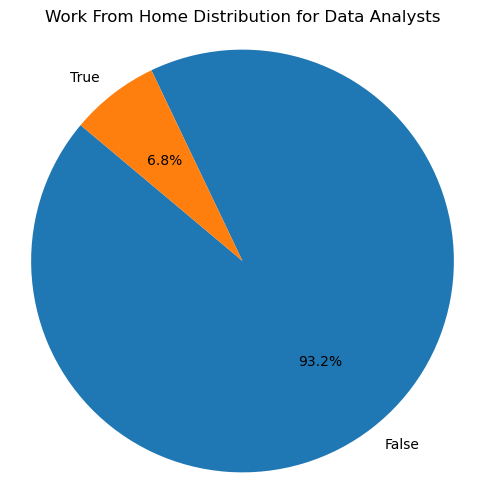

In [4]:
plt.figure(figsize=(6, 6))
plt.pie(work_from_home, labels=work_from_home.index, autopct='%1.1f%%', startangle=140)
plt.title('Work From Home Distribution for Data Analysts')
plt.axis('equal')
plt.show()

In [5]:
job_no_degree = df_da["job_no_degree_mention"].value_counts()
job_no_degree.head()

job_no_degree_mention
False    120243
True      75832
Name: count, dtype: int64

In [6]:
job_health_insurance = df["job_health_insurance"].value_counts()
job_health_insurance.head()

job_health_insurance
False    699244
True      86497
Name: count, dtype: int64

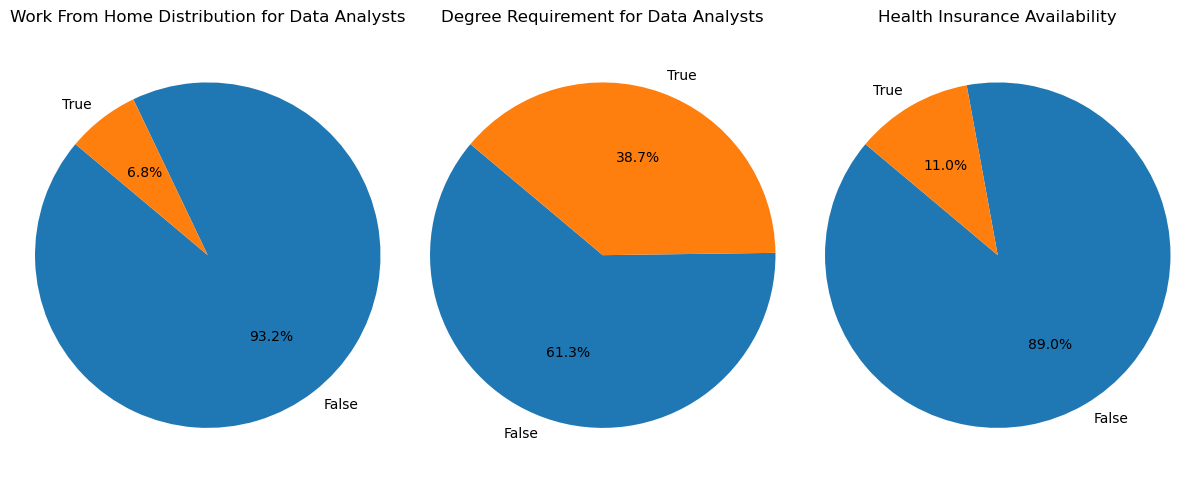

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))

# Data Analyst Salaries
plt.subplot(1, 3, 1)
plt.pie(work_from_home, labels=work_from_home.index, autopct='%1.1f%%', startangle=140)
plt.title('Work From Home Distribution for Data Analysts')
plt.axis('equal')

# Data Analyst Degree Requirement
plt.subplot(1, 3, 2)
plt.pie(job_no_degree, labels=job_no_degree.index, autopct='%1.1f%%', startangle=140)
plt.title('Degree Requirement for Data Analysts')
plt.axis('equal')

# Overall Health Insurance
plt.subplot(1, 3, 3)
plt.pie(job_health_insurance, labels=job_health_insurance.index, autopct='%1.1f%%', startangle=140)
plt.title('Health Insurance Availability')
plt.axis('equal')

plt.tight_layout()
plt.show()

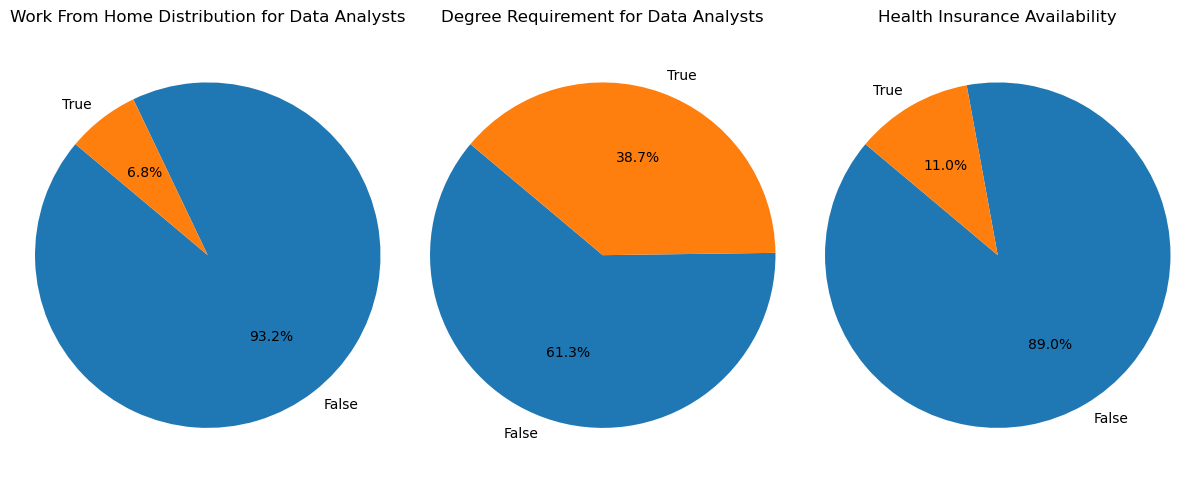

In [8]:
# Rewrite the above with a for loop to avoid code repetition
data = [work_from_home, job_no_degree, job_health_insurance]
titles = ['Work From Home Distribution for Data Analysts', 'Degree Requirement for Data Analysts', 'Health Insurance Availability']

fig, ax = plt.subplots(1, 3, figsize=(12, 5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.pie(data[i], labels=data[i].index, autopct='%1.1f%%', startangle=140)
    plt.title(titles[i])
    plt.axis('equal')
plt.tight_layout()
plt.show()

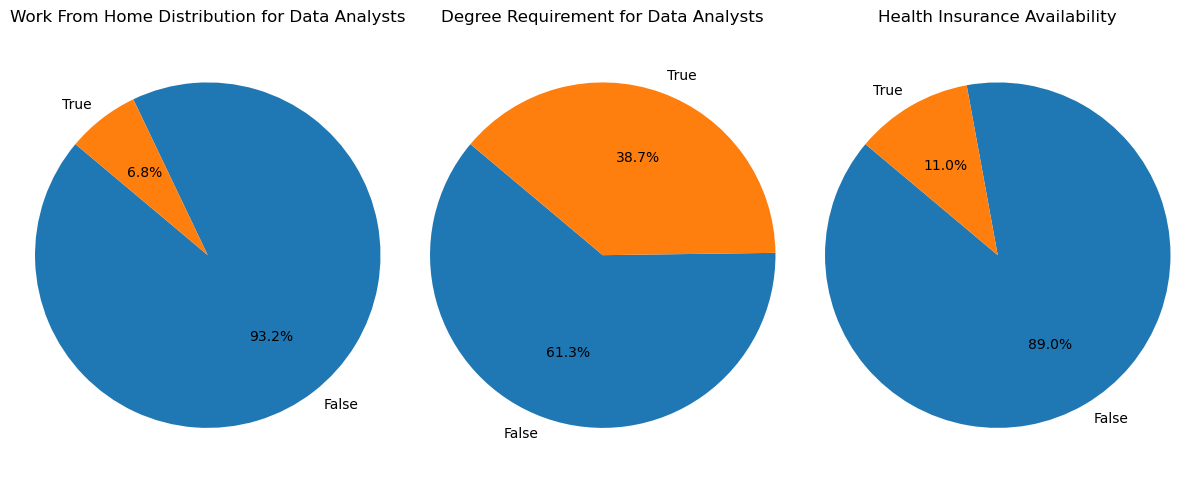

In [9]:
# Another way of using for loop with enumerate function
fig, ax = plt.subplots(1, 3, figsize=(12, 5))
for i, dataset in enumerate(data):
    plt.subplot(1, 3, i+1)
    plt.pie(dataset, labels=dataset.index, autopct='%1.1f%%', startangle=140)
    plt.title(titles[i])
    plt.axis('equal')
plt.tight_layout()
plt.show()

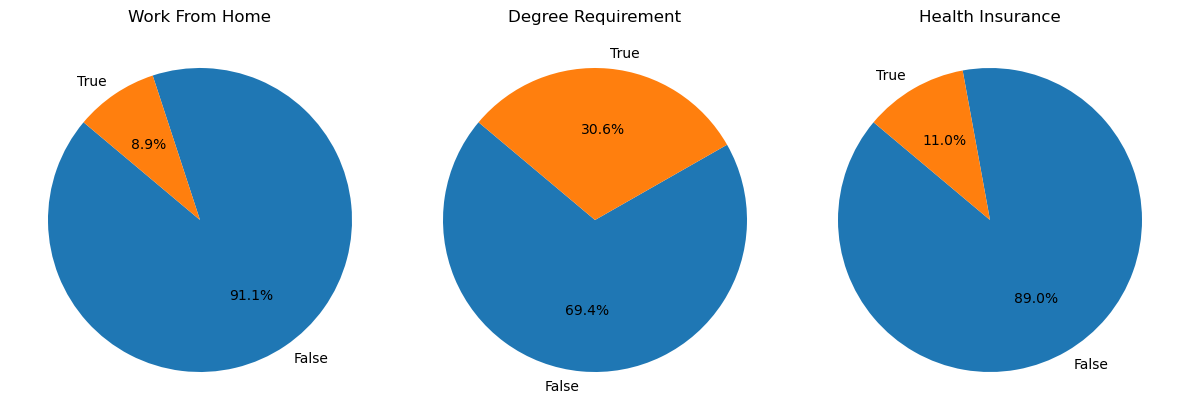

In [10]:
dict_columns = {
    'job_work_from_home': "Work From Home", 
    'job_no_degree_mention': "Degree Requirement", 
    'job_health_insurance': "Health Insurance"
}

fig, ax = plt.subplots(1, 3, figsize=(12, 5))

for i, (column, title) in enumerate(dict_columns.items()):
    counts = df[column].value_counts()  # get numeric counts
    ax[i].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140)
    ax[i].set_title(title)

plt.tight_layout()
plt.show()